# Saturácia kyslíkom- Numerický aj kategorický

In [ ]:
pip install xgboost catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 8.2 MB/s eta 0:00:00


In [ ]:
pip install shap==0.44.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.7/535.7 kB 3.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from math import sqrt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from lightgbm import LGBMRegressor
import xgboost as xgb
import catboost as cb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import shap
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
%matplotlib inline


In [ ]:
#sns.set(style="whitegrid")

In [ ]:
data = pd.read_excel("data_no_missing.xlsx")
original_data = data.copy()
data

,Derivation cohort,LOS,Death,Severity,Black,White,Asian,Latino,MI,PVD,...,Glucose,AST,ALT,WBC,Lympho,IL6,Ferritin,CrctProtein,Procalcitonin,Troponin
0,1,3,0,6,1,0,0,0,0,0,...,132,54.000,26.0,7.4,1.2,48.2000,1962.0,27.3000,0.3000,0.00999
1,1,6,0,4,0,1,0,0,0,0,...,115,135.000,243.0,5.9,1.1,5.3000,3043.0,11.1000,1.6000,0.01000
2,1,1,0,2,1,0,0,0,0,1,...,182,23.000,19.0,7.1,2.9,3.9999,87.0,0.8000,0.0999,0.00999
3,1,3,0,5,1,0,0,0,0,0,...,159,45.000,33.0,7.1,0.6,3.9999,3464.0,3.0000,1.3000,0.23000
4,1,14,0,3,0,0,0,1,0,0,...,127,84.000,43.0,3.6,0.4,11.8000,994.0,14.5000,0.2000,0.01000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,0,3,0,1,1,0,0,0,0,0,...,110,19.999,12.0,14.7,3.1,10.8000,254.0,1.9000,0.3000,0.01000
868,0,2,0,2,0,0,0,0,0,0,...,150,51.000,35.0,6.2,0.8,70.9000,184.0,4.1000,0.1000,0.01000
869,0,2,0,1,0,0,0,1,0,0,...,131,58.000,81.0,7.0,1.5,3.9999,73.0,0.4999,0.1000,0.01000
870,0,6,0,5,0,0,0,0,0,1,...,224,36.000,15.0,6.6,1.2,5.4000,750.0,21.1000,0.3000,0.01000


In [ ]:
# Renaming columns
data = data.rename(columns={
    'LOS': 'Length_of_stay',
    'MI': 'Myocardial_infarction',
    'PVD': 'Per_vascular_dis',
    'CHF': 'Cong_heart_failure',
    'CVD': 'Cardiovascular_dis',
    'DEMENT': 'Dementia',
    'COPD': 'Chronic_obst_pulm_dis',
    'DM Complicated': 'Diabetes_mel_complicated',
    'DM Simple': 'Diabetes_mel_simple',
    'Renal Disease': 'Renal_dis',
    'All CNS': 'All_CNS',
    'Pure CNS': 'Pure_CNS',
    'OldOtherNeuro': 'Other_neuro_dis',
    'OtherBrnLsn': 'Other_brain_lesions',
    'Age.1': 'Age_number',
    'AgeScore': 'Age_category',
    'OsSats': 'Oxygen_sat',
    'Temp': 'Temperature',
    'MAP': 'Mean_art_press',
    'Plts': 'Platelets',
    'INR': 'Inter_norm_ratio',
    'BUN': 'Blood_urea_nitr',
    'WBC': 'White_blood_cells',
    'CrctProtein': 'CRP'
})


In [ ]:
data['Per_vascular_dis'] = data['Per_vascular_dis'].replace(2, 1)

In [ ]:
data_copy = data.copy()

In [ ]:
# Convert the column to float
data['Procal_int'] = data['Procalcitonin'].astype(int)

## Popis cieľového atribútu

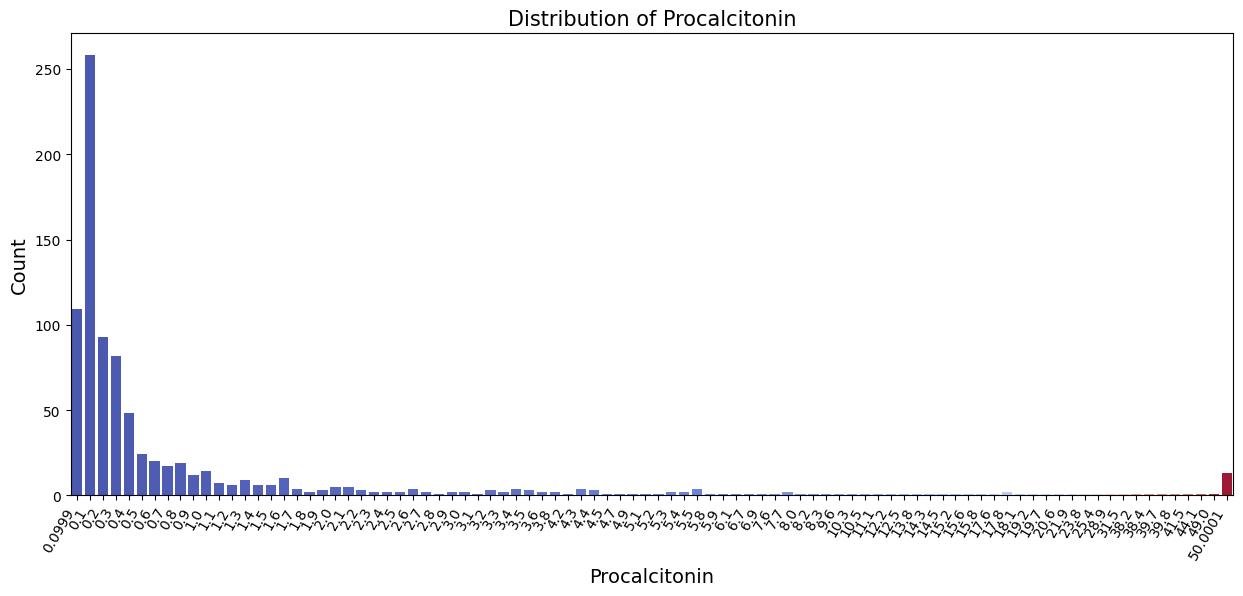

In [ ]:
plt.figure(figsize=(15, 6))
sns.countplot(data=data, x="Procalcitonin", hue="Procalcitonin", palette="coolwarm", legend=False)

# Get current axis
ax = plt.gca()

# Adding a title to the x-axis and y-axis
ax.set_xlabel("Procalcitonin", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
plt.xticks(rotation=60, ha='right')
plt.title("Distribution of Procalcitonin", fontsize=15)
plt.show()


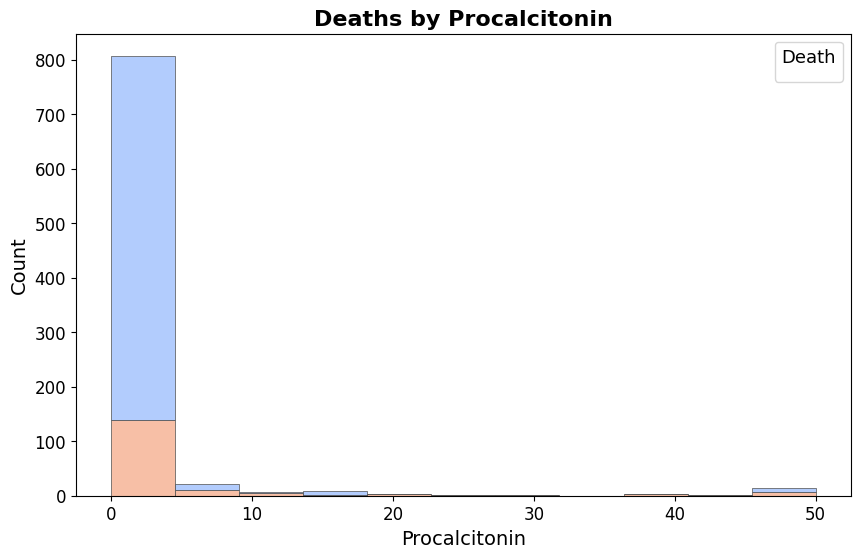

In [ ]:
plt.figure(figsize=(10, 6))  # Slightly larger figure size for better clarity
plt.title('Deaths by Procalcitonin', fontsize=16, fontweight='bold')

# Enhanced histogram plot
sns.histplot(
    x='Procal_int',
    hue='Death',
    multiple="stack",
    data=data,
    palette="coolwarm",
    edgecolor='.3',
    linewidth=.5,
    alpha=0.9
)

plt.xlabel('Procalcitonin', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Death', title_fontsize='13', fontsize='12', loc='upper right')
plt.show()


<Axes: title={'center': 'Deaths by Procalcitonin'}, xlabel='Procal_int', ylabel='Count'>

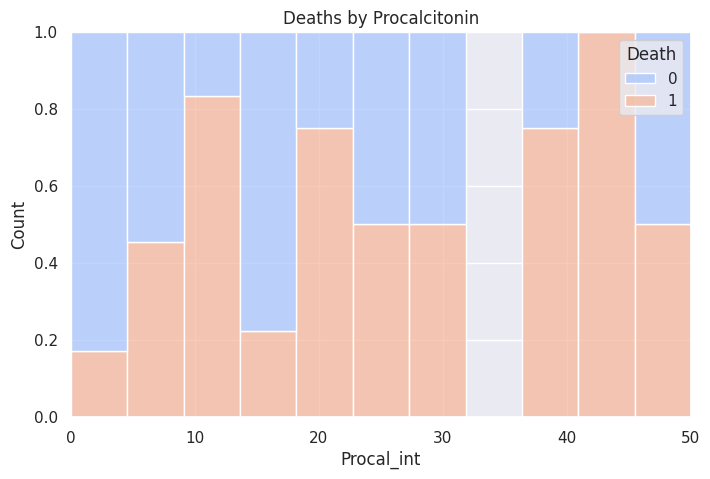

In [ ]:
import seaborn as sns
sns.set()
plt.figure(figsize=(8,5))
plt.title('Deaths by Procalcitonin')
sns.histplot(x='Procal_int', hue='Death',multiple="fill", data=data, palette="coolwarm")

Ignoring `palette` because no `hue` variable has been assigned.


<Axes: xlabel='Oxygen_sat', ylabel='Procalcitonin'>

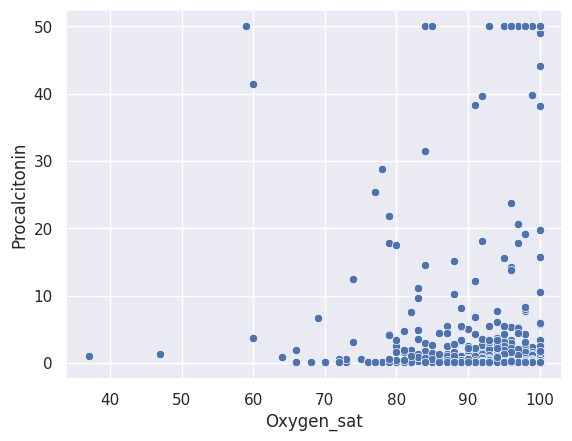

In [ ]:
sns.scatterplot(x="Oxygen_sat", y="Procalcitonin",  data=data, palette="dark")

In [ ]:
data = data.drop("Procal_int", axis=1)

# Rozdelenie atribútov na numerické a kategorické

In [ ]:
numeric_features = data.columns[data.nunique() > 10]
numeric_features = numeric_features.drop("Severity")
print("Columnns that contain more than 10 values:\n", numeric_features)
print("Number of nuemrical features:", numeric_features.size)

Columnns that contain more than 10 values:
 Index(['Length_of_stay', 'Age2', 'Oxygen_sat', 'Temperature', 'Mean_art_press',
       'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr',
       'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells',
       'Lympho', 'IL6', 'Ferritin', 'CRP', 'Procalcitonin', 'Troponin'],
      dtype='object')
Number of nuemrical features: 21


In [ ]:
categorical_features = data.columns[data.nunique() <=4]
categorical_features = categorical_features.drop("Death")
print("Columnns that contain less than 10 values:\n", categorical_features)
print("Number of categorical features:", categorical_features.size)

Columnns that contain less than 10 values:
 Index(['Derivation cohort', 'Black', 'White', 'Asian', 'Latino',
       'Myocardial_infarction', 'Per_vascular_dis', 'Cong_heart_failure',
       'Cardiovascular_dis', 'Dementia', 'Chronic_obst_pulm_dis',
       'Diabetes_mel_complicated', 'Diabetes_mel_simple', 'Renal_dis',
       'All_CNS', 'Pure_CNS', 'Stroke', 'Seizure', 'OldSyncope',
       'Other_neuro_dis', 'Other_brain_lesions', 'Age_category', 'PltsScore',
       'CrtnScore'],
      dtype='object')
Number of categorical features: 24


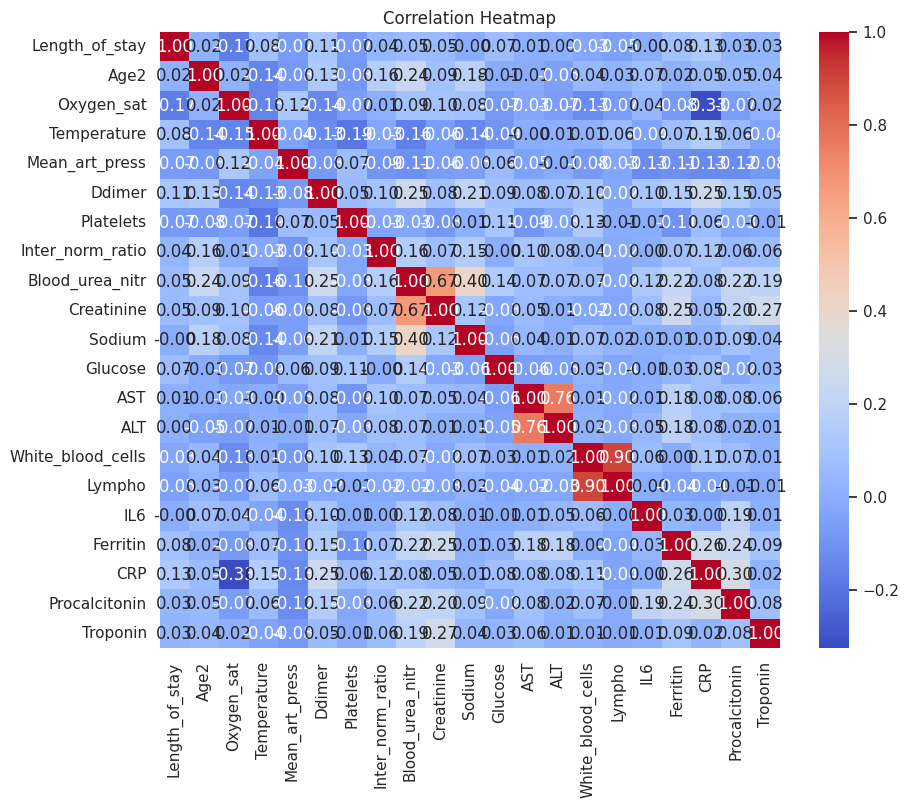

In [ ]:
# Calculate the correlation matrix
correlation_matrix = data[numeric_features].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


# Log transformácia (data_copy) numerických atribútov kvôli štatistickým testom

### Výber numerických atribútov

In [ ]:
#show only column names with more than 2 unique values, discarding all boolean ones.
cols = ((data.dtypes != 'object') & (data.nunique() > 2))
cols = cols.drop(['CrtnScore','PltsScore','Age_category'])

selectedColumns = list(cols[cols].index)
print(selectedColumns)
print(len(selectedColumns))

['Length_of_stay', 'Severity', 'Age2', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'IL6', 'Ferritin', 'CRP', 'Procalcitonin', 'Troponin']
22


## 2. Log transformation of DATA COPY

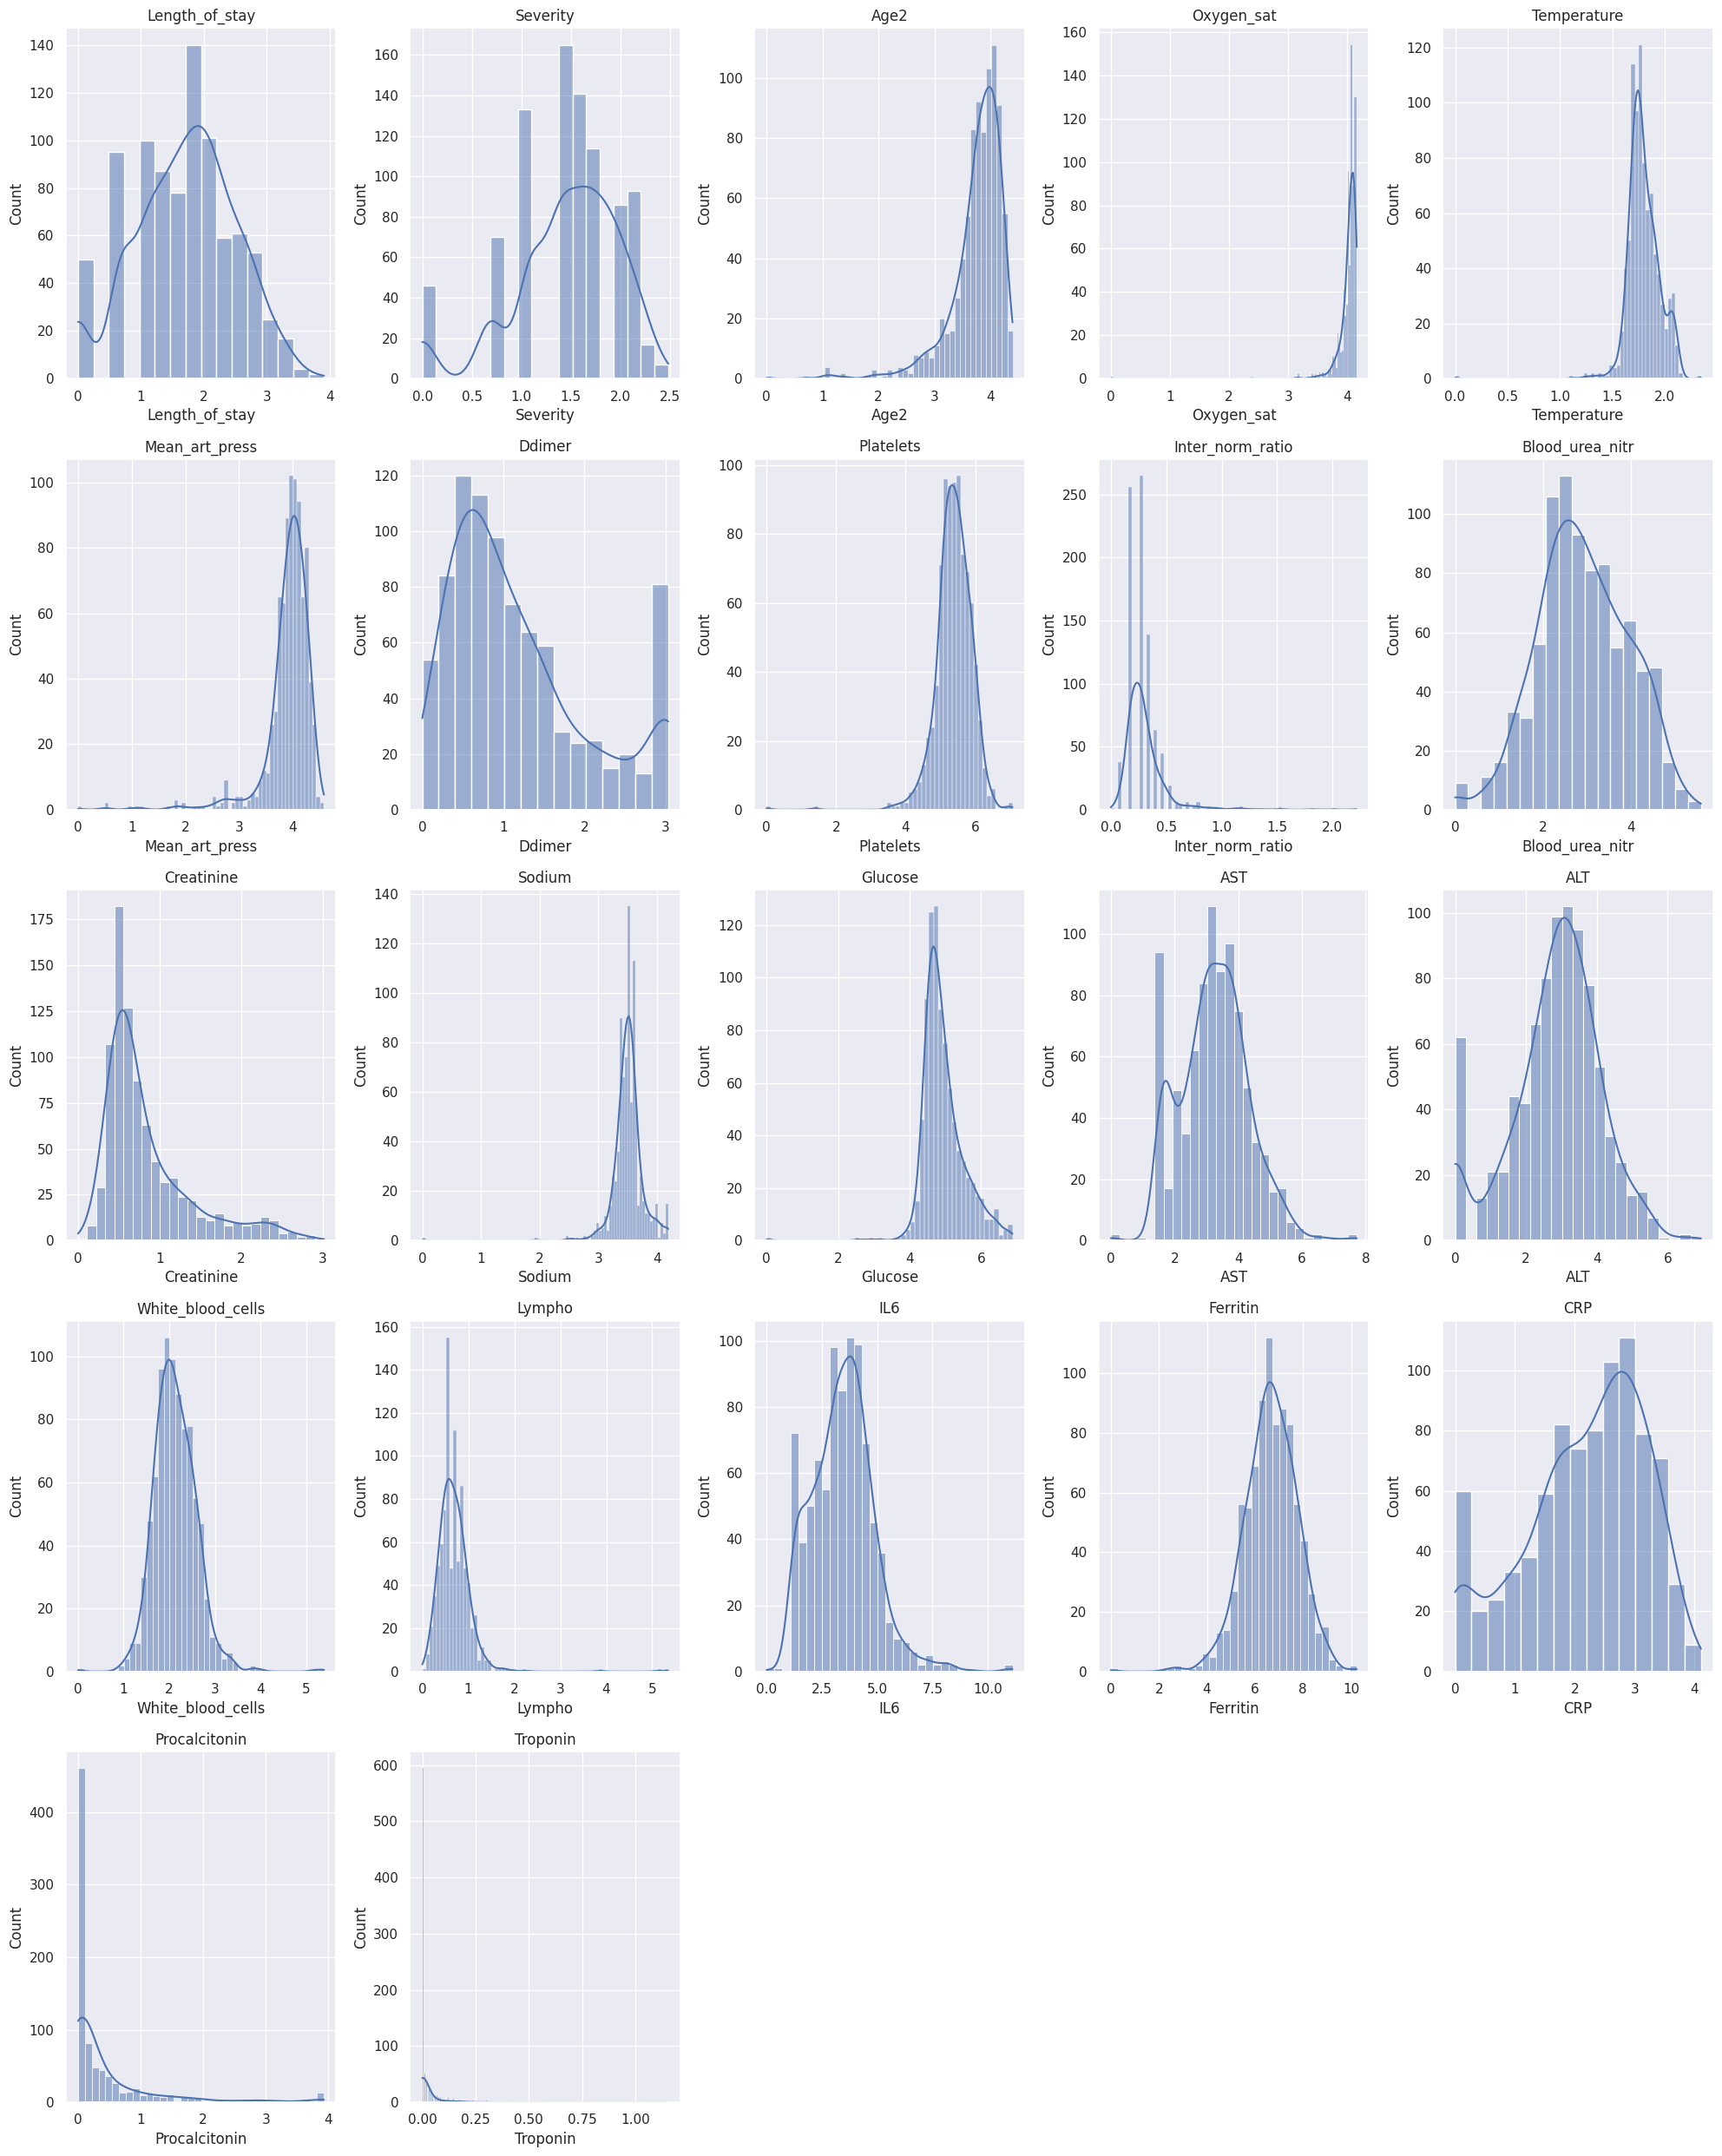

In [ ]:

data_copy[selectedColumns] = data_copy[selectedColumns] + 1 - data_copy[selectedColumns].min()

# Apply log transformation
data_copy[selectedColumns] = np.log(data_copy[selectedColumns])

num_plots_in_row = 5
num_rows = (len(selectedColumns) + num_plots_in_row - 1) // num_plots_in_row
fig, axes = plt.subplots(nrows=num_rows, ncols=num_plots_in_row, figsize=(20, 5 * num_rows))

# Flatten the axes if there is more than one row
axes = axes.flatten()

# Plot the distribution of each numeric column
for i, column in enumerate(selectedColumns):
    sns.histplot(data_copy[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

# Remove any empty subplots
for j in range(len(selectedColumns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE

In [ ]:
sns.set_style("ticks")

## Spearmanov koeficient



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



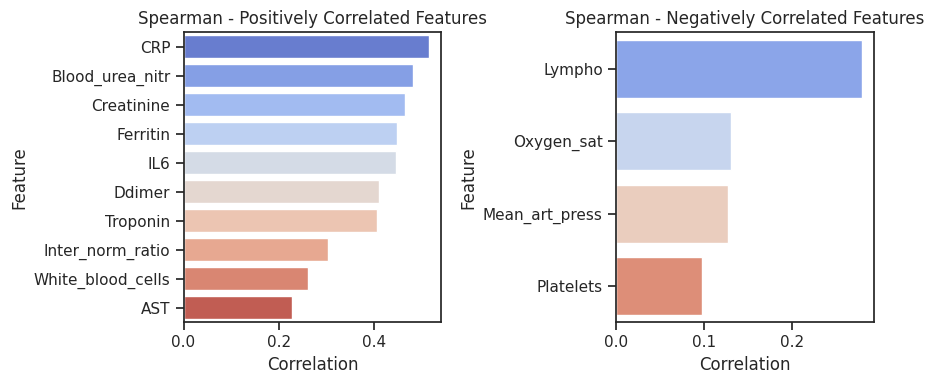

In [ ]:
# Specify the target variable
target_feature = 'Procalcitonin'

# Calculate Spearman correlation coefficients with the target variable
corr_with_target = data_copy[numeric_features].corr(method='spearman')[target_feature].drop(target_feature)

# Split correlations into positive and negative
positive_correlations = corr_with_target[corr_with_target > 0]
negative_correlations = corr_with_target[corr_with_target < 0]

# Sort the correlations by their absolute values in descending order
positive_correlations_sorted = positive_correlations.sort_values(ascending=False)
negative_correlations_sorted = negative_correlations.abs().sort_values(ascending=False)

# Extract the top correlated features (both positively and negatively)
n_top_features = 10

# Plot the most positively correlated features
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Spearman - Positively Correlated Features')

# Plot the most negatively correlated features
plt.subplot(1, 2, 2)
sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Spearman - Negatively Correlated Features')

plt.tight_layout()
plt.show()

## Kendallov koeficient pre zistenie vplyvu kategorických atr. na numerický



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



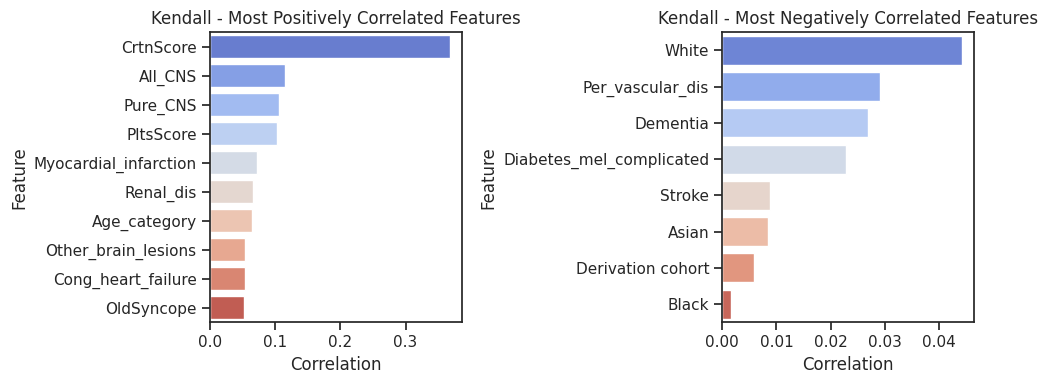

In [ ]:
target_feature = 'Procalcitonin'
corr_with_target = data_copy[categorical_features].apply(lambda x: x.corr(data_copy[target_feature], method='kendall'))

# Split correlations into positive and negative
positive_correlations = corr_with_target[corr_with_target > 0]
negative_correlations = corr_with_target[corr_with_target < 0]

# Sort the correlations by their absolute values in descending order
positive_correlations_sorted = positive_correlations.sort_values(ascending=False)
negative_correlations_sorted = negative_correlations.abs().sort_values(ascending=False)

# Extract the top correlated features (both positively and negatively)
n_top_features = 10

# Plot the most positively correlated features
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Kendall - Most Positively Correlated Features')

# Plot the most negatively correlated features
plt.subplot(1, 2, 2)
sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Kendall - Most Negatively Correlated Features')

plt.tight_layout()
plt.show()


## ANOVA pre vplyv kategorických atr. na numerický

divide by zero encountered in divide


ANOVA Test Results:
Feature		P-Value
Seizure		0.0
Other_brain_lesions		5.558826557008173e-45
CrtnScore		3.1471909541805085e-22
OldSyncope		2.618524969383855e-13
Myocardial_infarction		2.1818840380141237e-11
All_CNS		8.1214568100737e-06
Pure_CNS		4.734687151650401e-05
Cong_heart_failure		0.0029478289469256303
Renal_dis		0.003433681345249893
PltsScore		0.008310345263415099
Asian		0.028033213473601708
Chronic_obst_pulm_dis		0.0329906678861041
Age_category		0.10253907369636442
White		0.1296297906461022
Other_neuro_dis		0.16672506698132702
Diabetes_mel_simple		0.16848072839093994
Latino		0.6322370784389653
Black		0.6482028081551805
Diabetes_mel_complicated		0.820637902011439
Derivation cohort		0.8713152456388802
Cardiovascular_dis		0.9146264084638039
Per_vascular_dis		0.9746757493980495
Dementia		0.9996361267995023
Stroke		0.9999999999999999


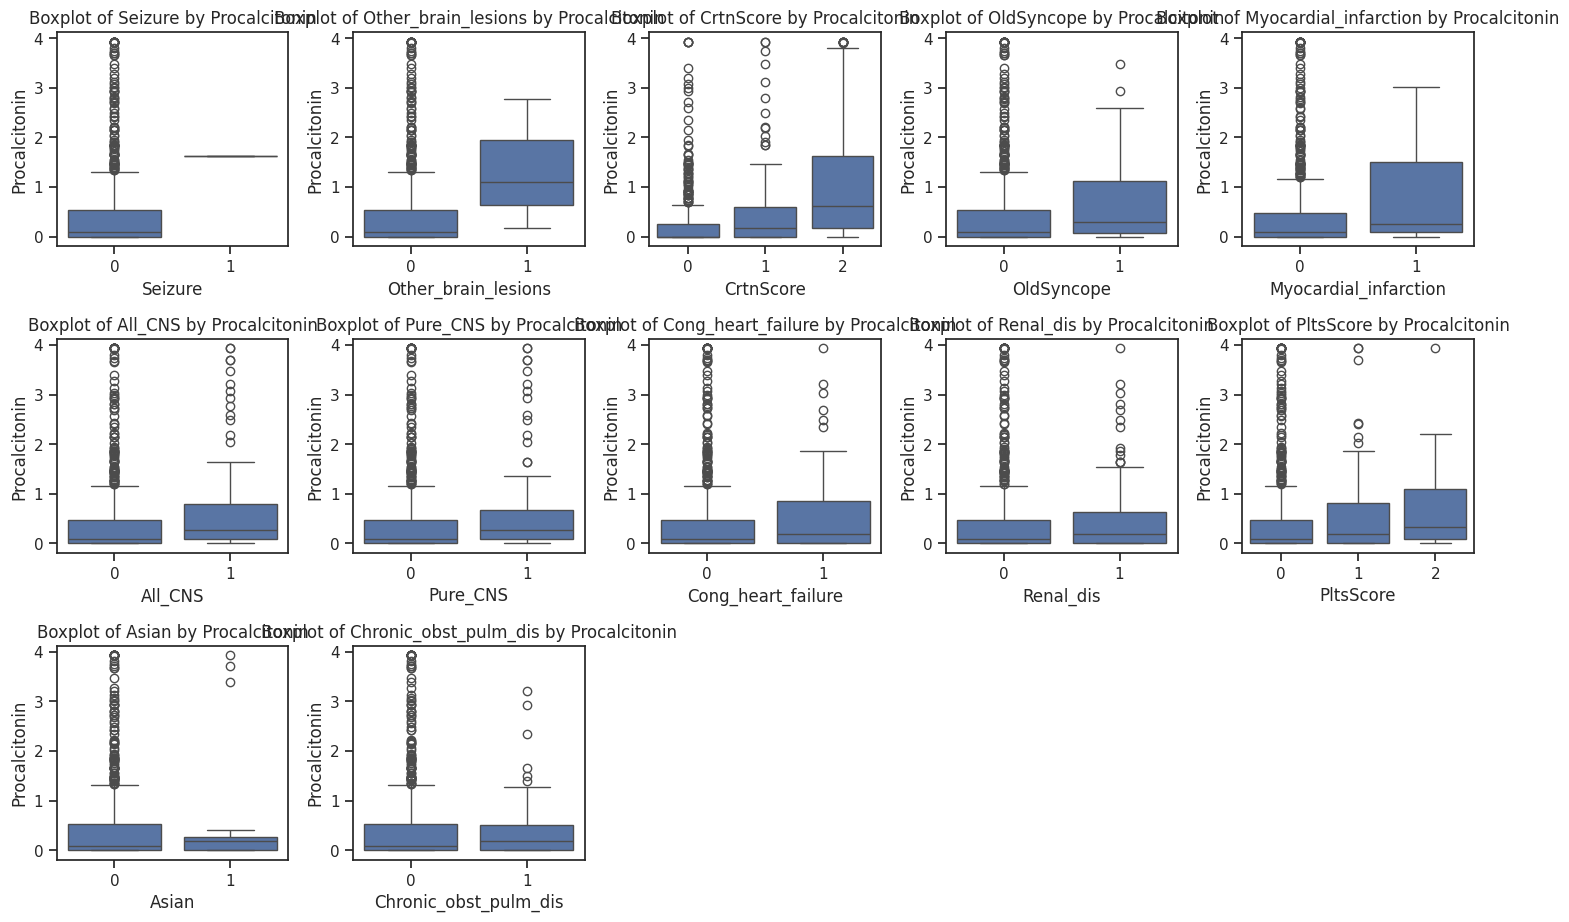

In [ ]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

df = pd.DataFrame(data_copy)

# Perform ANOVA test for numeric features
f_stat, p_values_anova = f_classif(df[categorical_features], df['Procalcitonin'])

# Display p-values in ascending order
print("ANOVA Test Results:")
print("Feature\t\tP-Value")
sorted_p_values_anova = sorted(zip(categorical_features, p_values_anova), key=lambda x: x[1])
for feature, p_value_anova in sorted_p_values_anova:
    print(f"{feature}\t\t{p_value_anova}")

# Visualize boxplots for significant features
significant_features = [feature for feature, p_value in sorted_p_values_anova if p_value < 0.05]

# Create subplots for boxplots
plt.figure(figsize=(15, 15))
for i, feature in enumerate(significant_features, 1):
    plt.subplot(5, 5, i)
    sns.boxplot(y='Procalcitonin', x=feature, data=df)
    plt.title(f'Boxplot of {feature} by Procalcitonin')
    plt.xlabel(feature)
    plt.ylabel('Procalcitonin')
plt.tight_layout()
plt.show()


## Boxplots na pôvodných dátach



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same e

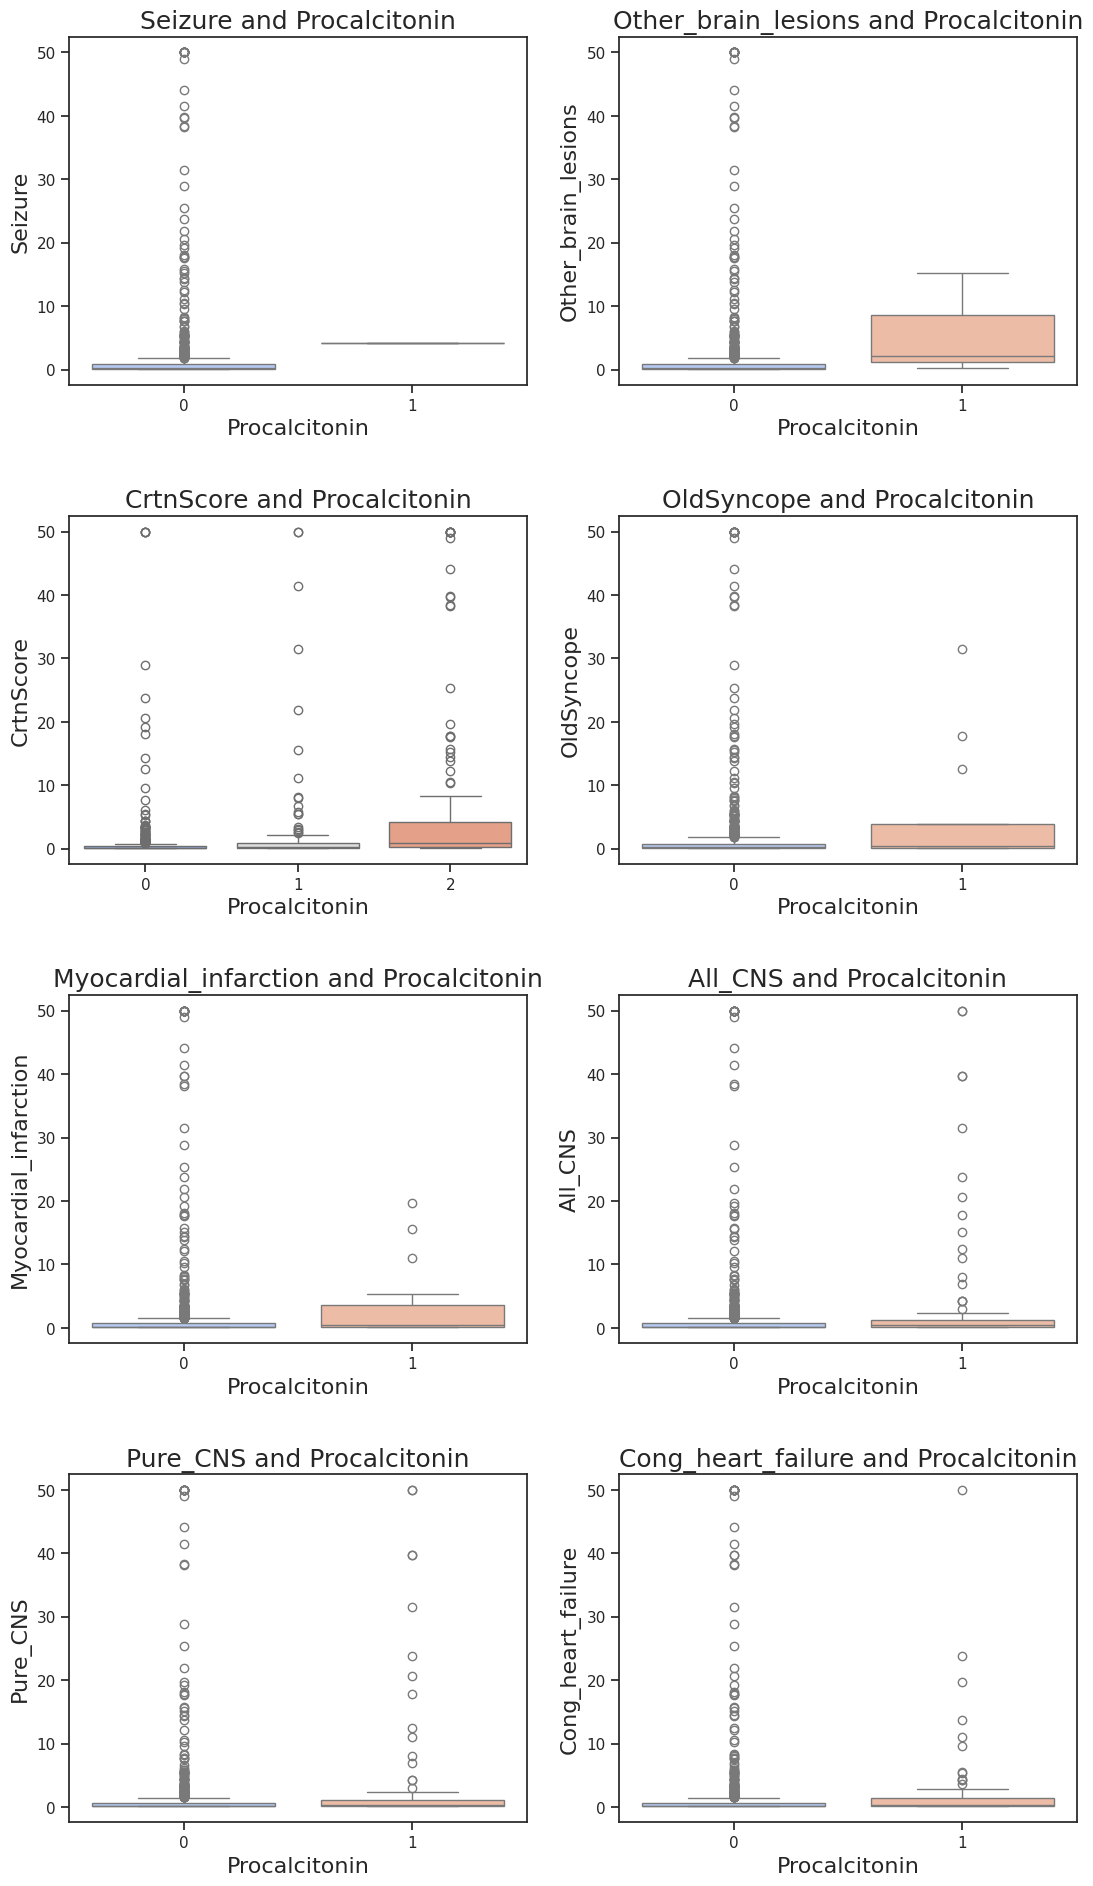

In [ ]:
top_8_features = significant_features[:8]

# Setup the matplotlib figure and axes for a 4x2 subplot layout
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 20))

# Flatten axes array for easy iterating
axes = axes.flatten()

# Iterate over the top 8 significant features and create boxplots
for i, feature in enumerate(top_8_features):
    sns.boxplot(x=feature, y="Procalcitonin", data=data, palette="coolwarm",  ax=axes[i])
    axes[i].set_title(f'{feature} and Procalcitonin', fontsize=18)
    axes[i].set_xlabel('Procalcitonin', fontsize=16)
    axes[i].set_ylabel(feature, fontsize=16)

plt.tight_layout(pad=4.0, h_pad=3.0, w_pad=2.0)

plt.show()

In [ ]:
feature_names=X.columns

# Normalizácia - pre modelovanie

### Výber numerických atribútov na normalizáciu, okrem cieľovej premennej atd


In [ ]:
#show only column names with more than 2 unique values, discarding all boolean ones.
cols = ((data.dtypes != 'object') & (data.nunique() > 2))
cols = cols.drop(['Procalcitonin', 'CrtnScore','PltsScore','Age_category'])

selectedColumns = list(cols[cols].index)
print(selectedColumns)
print(len(selectedColumns))

['Length_of_stay', 'Severity', 'Age2', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'IL6', 'Ferritin', 'CRP', 'Troponin']
21


Numeric features distributions

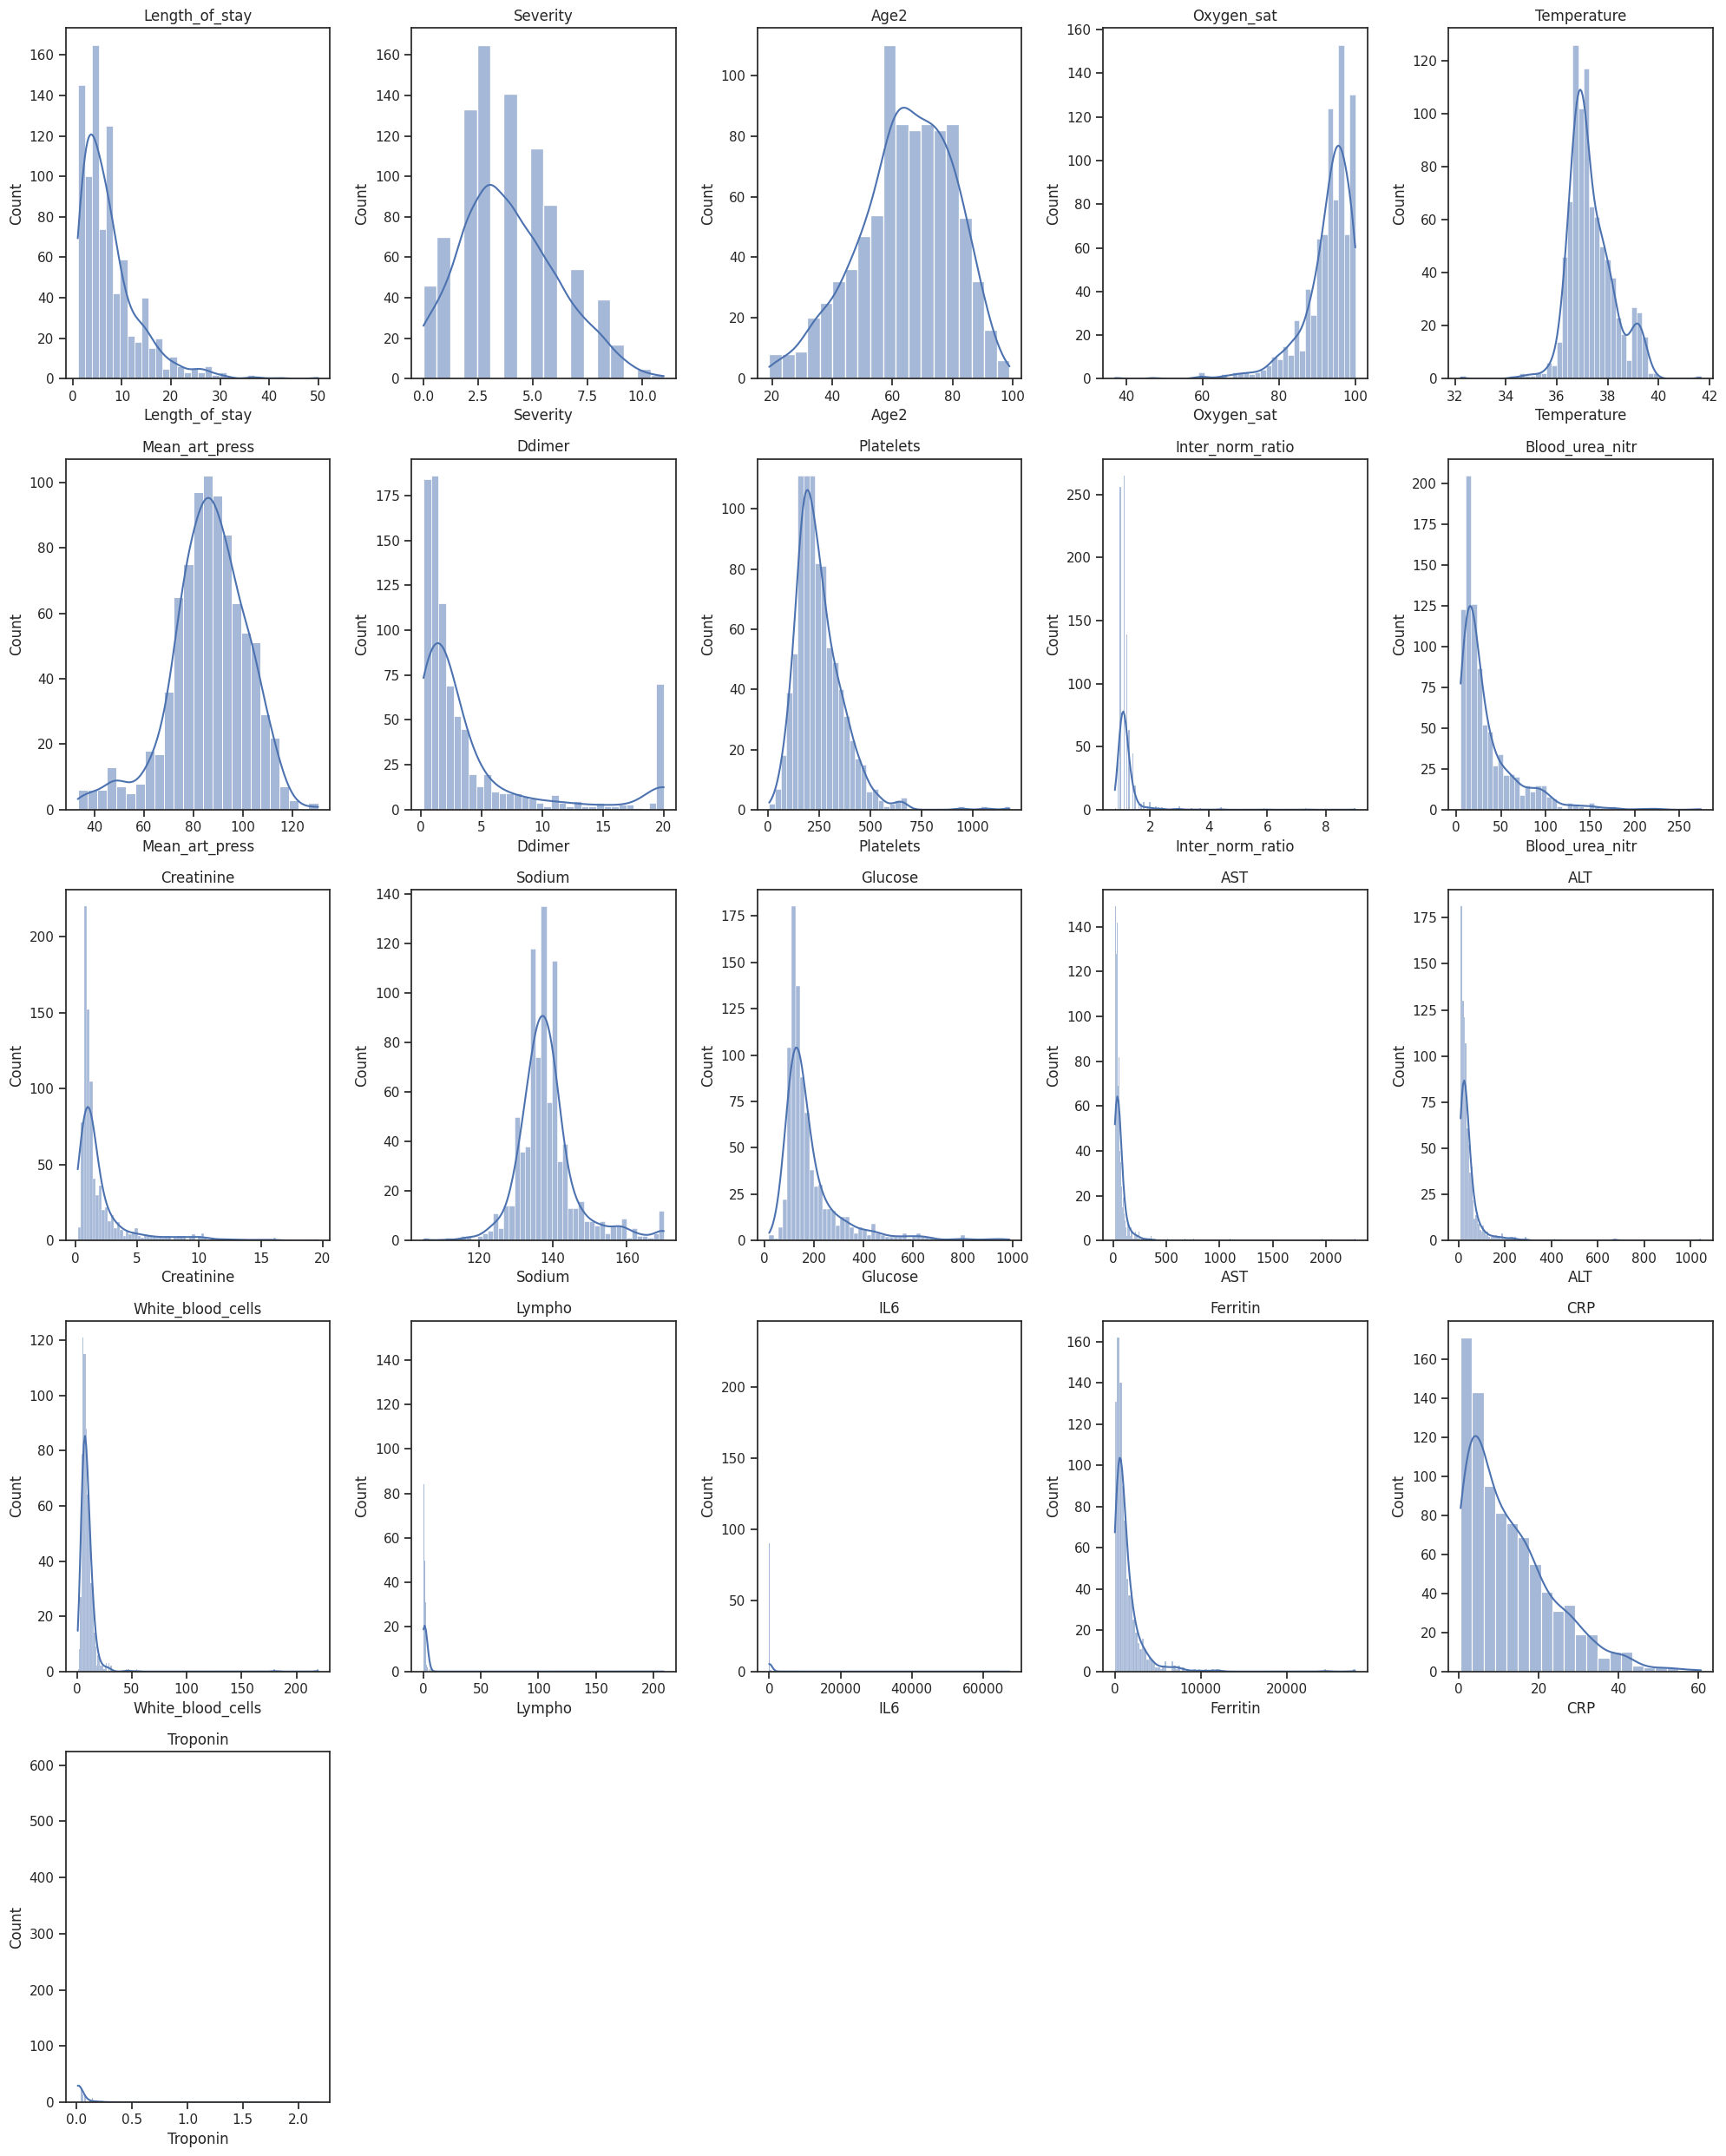

In [ ]:
num_plots_in_row = 5
num_rows = (len(selectedColumns) + num_plots_in_row - 1) // num_plots_in_row
fig, axes = plt.subplots(nrows=num_rows, ncols=num_plots_in_row, figsize=(20, 5 * num_rows))

# Flatten the axes if there is more than one row
axes = axes.flatten()

# Plot the distribution of each numeric column
for i, column in enumerate(selectedColumns):
    sns.histplot(data[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

# Remove any empty subplots
for j in range(len(selectedColumns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Standard Scaler

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler
# Select the columns you want to normalize
columns_to_normalize = selectedColumns

# Create a new df for the columns to normalize
data_to_normalize = data[columns_to_normalize]

# Normalize using Min-Max scaling
standard_scaler = StandardScaler()
data_to_normalize_minmax = standard_scaler.fit_transform(data_to_normalize)

# Update the original DataFrame with the normalized values
data[columns_to_normalize] = data_to_normalize_minmax

data.head(5)

,Derivation cohort,Length_of_stay,Death,Severity,Black,White,Asian,Latino,Myocardial_infarction,Per_vascular_dis,...,Glucose,AST,ALT,White_blood_cells,Lympho,IL6,Ferritin,CRP,Procalcitonin,Troponin
0,1,-0.735599,0,0.945490,1,0,0,0,0,0,...,-0.425913,-0.091402,-0.295404,-0.194421,-0.048318,-0.067319,0.292748,1.341902,0.3000,-0.253109
1,1,-0.241675,0,0.047377,0,1,0,0,0,0,...,-0.554445,0.576364,3.179095,-0.338855,-0.059171,-0.081546,0.841690,-0.156141,1.6000,-0.253046
2,1,-1.064882,0,-0.850735,1,0,0,0,0,1,...,-0.047879,-0.346967,-0.407485,-0.223308,0.136191,-0.081977,-0.659395,-1.108601,0.0999,-0.253109
3,1,-0.735599,0,0.496434,1,0,0,0,0,0,...,-0.221774,-0.165598,-0.183324,-0.223308,-0.113439,-0.081977,1.055478,-0.905163,1.3000,1.139518
4,1,1.075455,0,-0.401679,0,0,0,1,0,0,...,-0.463717,0.155919,-0.023209,-0.560319,-0.135146,-0.079390,-0.198812,0.158263,0.2000,-0.253046


## Vytvorenie pomocných "dummies" atribútov pre kategorické atribúty

In [ ]:
#  get_dummies to create dummy variables for each categorical column
data = pd.get_dummies(data, columns=['CrtnScore', 'PltsScore', 'Age_category'], prefix=['CrtnScore', 'PltsScore', 'AgeScore'])

data.head(5)

,Derivation cohort,Length_of_stay,Death,Severity,Black,White,Asian,Latino,Myocardial_infarction,Per_vascular_dis,...,CrtnScore_0,CrtnScore_1,CrtnScore_2,PltsScore_0,PltsScore_1,PltsScore_2,AgeScore_0,AgeScore_1,AgeScore_2,AgeScore_3
0,1,-0.735599,0,0.945490,1,0,0,0,0,0,...,True,False,False,True,False,False,False,False,False,True
1,1,-0.241675,0,0.047377,0,1,0,0,0,0,...,True,False,False,True,False,False,False,True,False,False
2,1,-1.064882,0,-0.850735,1,0,0,0,0,1,...,True,False,False,True,False,False,False,True,False,False
3,1,-0.735599,0,0.496434,1,0,0,0,0,0,...,False,False,True,True,False,False,False,False,True,False
4,1,1.075455,0,-0.401679,0,0,0,1,0,0,...,True,False,False,True,False,False,True,False,False,False


In [ ]:
data.columns

Index(['Derivation cohort', 'Length_of_stay', 'Death', 'Severity', 'Black',
       'White', 'Asian', 'Latino', 'Myocardial_infarction', 'Per_vascular_dis',
       'Cong_heart_failure', 'Cardiovascular_dis', 'Dementia',
       'Chronic_obst_pulm_dis', 'Diabetes_mel_complicated',
       'Diabetes_mel_simple', 'Renal_dis', 'All_CNS', 'Pure_CNS', 'Stroke',
       'Seizure', 'OldSyncope', 'Other_neuro_dis', 'Other_brain_lesions',
       'Age2', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer',
       'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine',
       'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'IL6',
       'Ferritin', 'CRP', 'Procalcitonin', 'Troponin', 'CrtnScore_0',
       'CrtnScore_1', 'CrtnScore_2', 'PltsScore_0', 'PltsScore_1',
       'PltsScore_2', 'AgeScore_0', 'AgeScore_1', 'AgeScore_2', 'AgeScore_3'],
      dtype='object')

In [ ]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5).fit(data_copy[numeric_features], data_copy['Procalcitonin'])
important_features = [feature for feature, coef in zip(numeric_features, lasso.coef_) if coef != 0]
print('Important features:', important_features)


Important features: ['Procalcitonin']


In [ ]:
X = data.drop(columns=["Death","Severity", "Procalcitonin"]) #

y = data["Procalcitonin"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and fitting the Lasso Regression model
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

# Making predictions
y_pred = lasso.predict(X_test)

# Calculating Mean Squared Error on test set
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Get the coefficients and corresponding feature names
coefficients = lasso.coef_
feature_names = [f'Feature {i}' for i in range(X.shape[1])]


Mean Squared Error: 33.603451936323175


## LASSO REGRESSION

In [ ]:
sns.set(style="whitegrid")

### Najlepšie alpha pre lasso regresiu

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.338e+00, tolerance: 3.794e+00
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.749e+03, tolerance: 3.682e+00
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.382e+01, tolerance: 4.658e+00
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.227e+01, tolerance: 3.194e+00
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.130e+03, tolerance: 4.685e+00
Objective did n

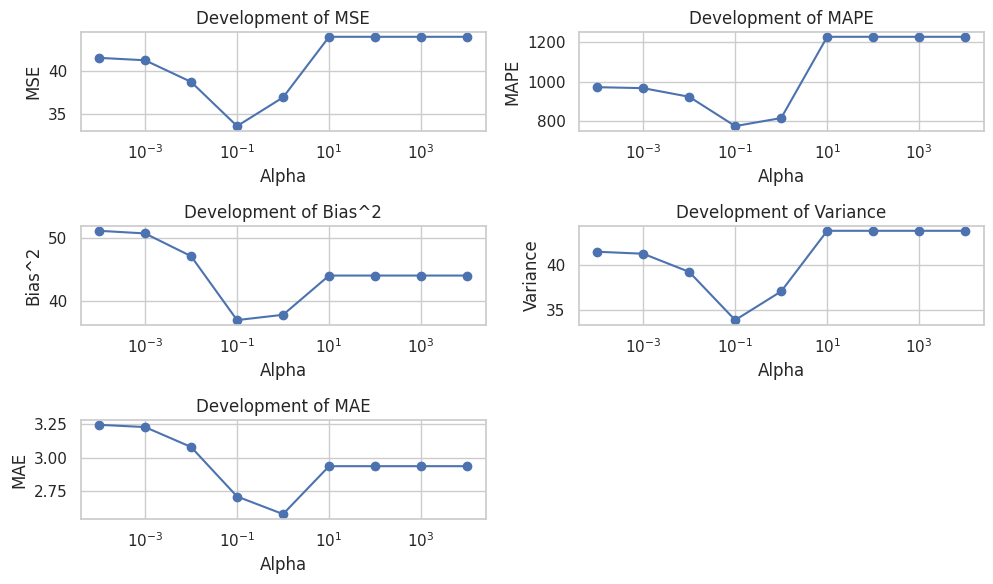

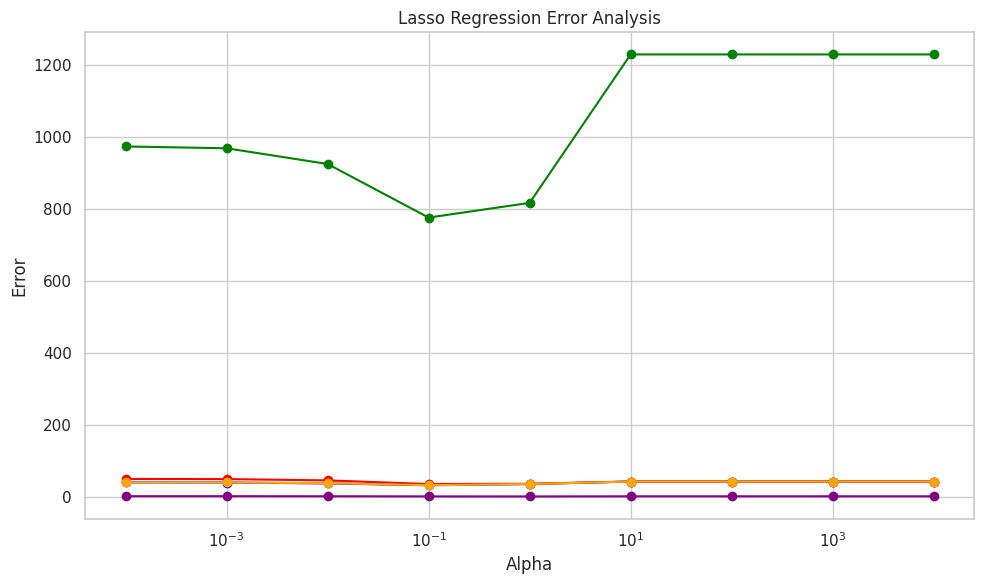

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
from mlxtend.evaluate import bias_variance_decomp

X = data.drop(columns=["Death","Severity","Procalcitonin"]).values
y = data['Procalcitonin'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a range of alpha values to be tested
alphas = np.logspace(-4, 4, 9)

# Create lists to store results
mse_values = []
mape_values = []
bias_squared_values = []
variance_values = []
mae_values = []

for alpha in alphas:

    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)

    # Calculate performance metrics
    mse = mean_squared_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    mae = mean_absolute_error(y_test, y_pred)

    # Bias-Variance Decomposition
    mse_train = mean_squared_error(y_train, lasso.predict(X_train))
    bias_squared, variance, noise = bias_variance_decomp(lasso, X_train, y_train, X_test, y_test, loss='mse', num_rounds=100, random_seed=42)

    # Append results to lists
    mse_values.append(mse)
    mape_values.append(mape)
    bias_squared_values.append(bias_squared)
    variance_values.append(variance)
    mae_values.append(mae)

# Plot results
plt.figure(figsize=(10, 6))

plt.subplot(3, 2, 1)
plt.plot(alphas, mse_values, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Development of MSE')

plt.subplot(3, 2, 2)
plt.plot(alphas, mape_values, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MAPE')
plt.title('Development of MAPE')

plt.subplot(3, 2, 3)
plt.plot(alphas, bias_squared_values, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Bias^2')
plt.title('Development of Bias^2')

plt.subplot(3, 2, 4)
plt.plot(alphas, variance_values, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Variance')
plt.title('Development of Variance')

plt.subplot(3, 2, 5)
plt.plot(alphas, mae_values, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MAE')
plt.title('Development of MAE')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))


plt.plot(alphas, mse_values, marker='o', color='blue', label = "MSE")
plt.plot(alphas, mape_values, marker='o', color= 'green', label = "MAPE")
plt.plot(alphas, bias_squared_values, marker='o', color= 'red', label = "Bias^2")
plt.plot(alphas, variance_values, marker='o', color = 'orange', label = "Variance")
plt.plot(alphas, mae_values, marker='o', color = 'purple', label = "MAE")

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Error')
plt.title('Lasso Regression Error Analysis')
plt.tight_layout()
plt.show()

### Bias, variance and mae

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.338e+00, tolerance: 3.794e+00
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.749e+03, tolerance: 3.682e+00
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.382e+01, tolerance: 4.658e+00
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.227e+01, tolerance: 3.194e+00
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.130e+03, tolerance: 4.685e+00
Objective did n

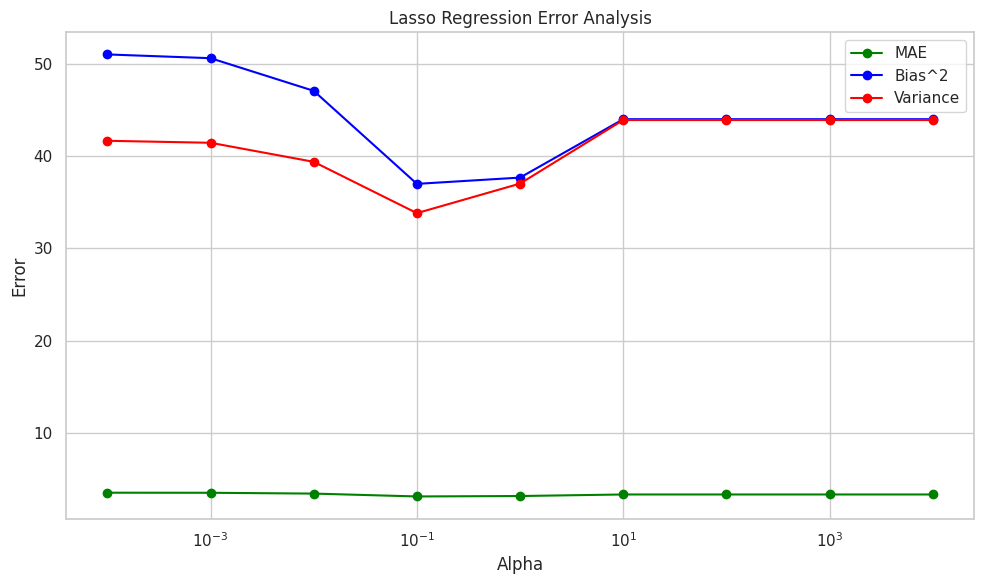

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from mlxtend.evaluate import bias_variance_decomp


# Define a range of alpha values to be tested
alphas = np.logspace(-4, 4, 9)

# Create lists to store results
mae_values = []
bias_squared_values = []
variance_values = []

# Iterate over alpha values
for alpha in alphas:
    # Fit Lasso regression
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)

    # Bias-Variance Decomposition
    bias_squared, variance, _ = bias_variance_decomp(lasso, X_train, y_train, X_test, y_test, loss='mse', num_rounds=200, random_seed=42)

    # Calculate MAE for the training set
    mae_train = mean_absolute_error(y_train, lasso.predict(X_train))

    mae_values.append(mae_train)
    bias_squared_values.append(bias_squared)
    variance_values.append(variance)

# Plot results
plt.figure(figsize=(10, 6))

plt.plot(alphas, mae_values, label='MAE', marker='o', color='green')
plt.plot(alphas, bias_squared_values, label='Bias^2', marker='o', color='blue')
plt.plot(alphas, variance_values, label='Variance', marker='o', color='red')

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Error')
plt.title('Lasso Regression Error Analysis')
plt.legend()
plt.tight_layout()
plt.show()


### LASSO s najlepšou alpha

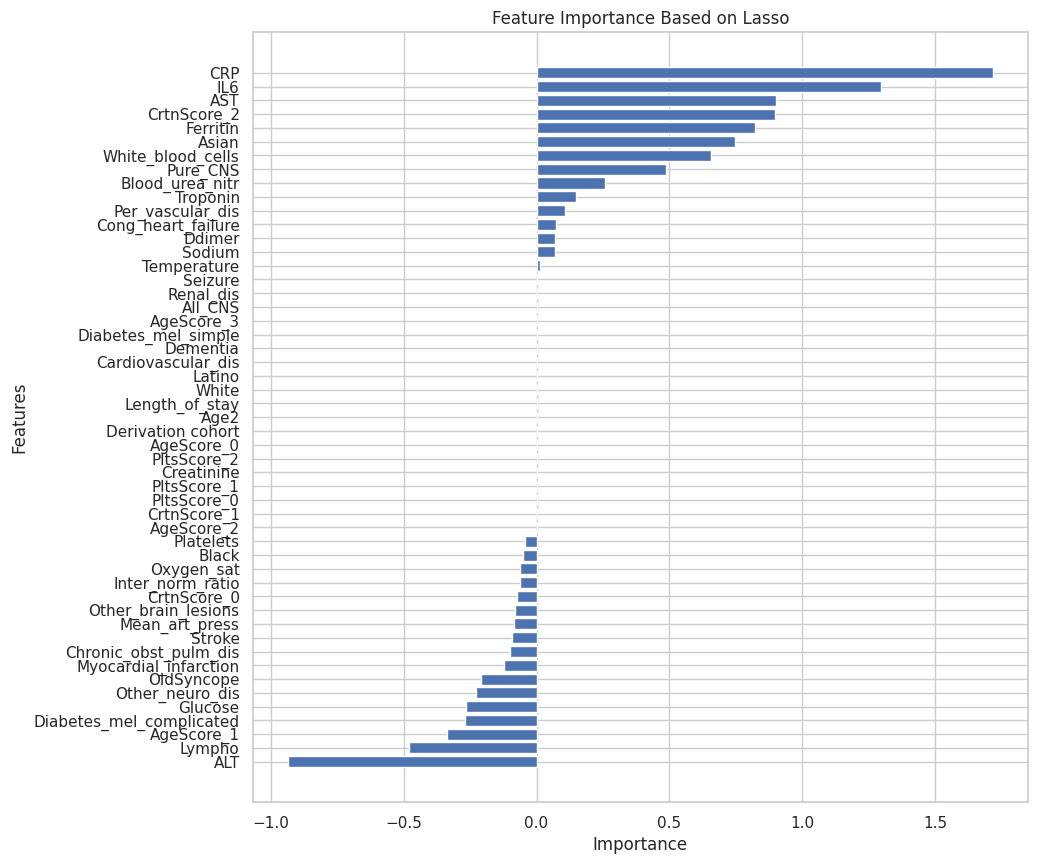

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=["Death","Severity", "Procalcitonin"]) #

y = data["Procalcitonin"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

# Getting the coefficients
coefficients = lasso.coef_

# Sort feature importance coefficients
sorted_indices = np.argsort(coefficients)

# Get sorted feature names and importance values
sorted_features = np.array(X_train.columns)[sorted_indices]
sorted_importance = coefficients[sorted_indices]

plt.figure(figsize=(10,10))
plt.barh(sorted_features, sorted_importance)
plt.grid(True)
plt.title("Feature Importance Based on Lasso")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

# Modelling PROCALCITONIN for SHAP values

In [ ]:
data = data[data['Procalcitonin'] <= 50]

In [ ]:
X = data.drop(columns=["Death","Severity","Procalcitonin"])

y = data["Procalcitonin"]

In [ ]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X,y, test_size=0.2, random_state=42)
print("Train_x :",train_x.shape)
print("Test_x :",test_x.shape)
print("Train_y :",train_y.shape)
print("Test_y :",test_y.shape)

Train_x : (687, 51)
Test_x : (172, 51)
Train_y : (687,)
Test_y : (172,)


# Všetky modely - porovnanie podľa MAE

In [ ]:

# Define regression models to test
models = [
    ('LinearRegression', LinearRegression()),
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('RandomForest', RandomForestRegressor()),
    ('LGBMRegressor', LGBMRegressor()),
    ('SVR', SVR()),
    ('KNN', KNeighborsRegressor()),
    ('XGBRegressor', xgb.XGBRegressor()),
    ('CatBoostRegressor', cb.CatBoostRegressor(verbose=0)),
    # Adding a placeholder for the Sequential model; we'll handle it separately
    #('SequentialNN', 'placeholder_for_keras_model')
]

results_table = []

for name, model in models:
    if name == 'SequentialNN':
        # Create and train the Sequential model
        model = create_sequential_model((train_x.shape[1],))
        history = model.fit(train_x, train_y, epochs=10, batch_size=32, verbose=0)
        predictions = model.predict(test_x).flatten()  # Flatten predictions
    else:
        # Train the model
        model.fit(train_x, train_y)
        # Make predictions
        predictions = model.predict(test_x)

    # Calculate metrics
    mae = mean_absolute_error(test_y, predictions)
    mse = mean_squared_error(test_y, predictions)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(test_y, predictions)

    # Store results
    results_table.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    })

# Convert results table to a DataFrame for better visualization
results_df = pd.DataFrame(results_table)

# Round the DataFrame to three decimal places
results_df = results_df.round(3)
results_df.sort_values(by='MAE', inplace=True)
print(results_df)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2198
[LightGBM] [Info] Number of data points in the train set: 687, number of used features: 45
[LightGBM] [Info] Start training from score 1.254864
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

## CatBoost Regressor - SHAP Vaelus

Mean Absolute Error: 2.1267679752724944
MSE: 35.64677930810112
RMSE: 5.970492384058548
R²: 0.34322606243730425


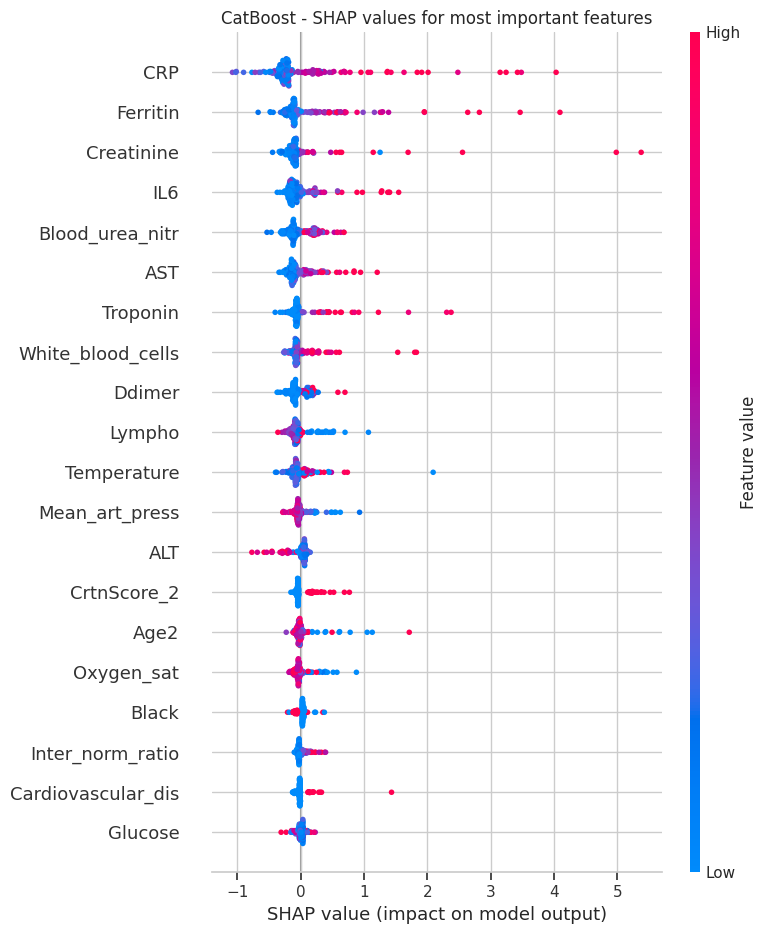

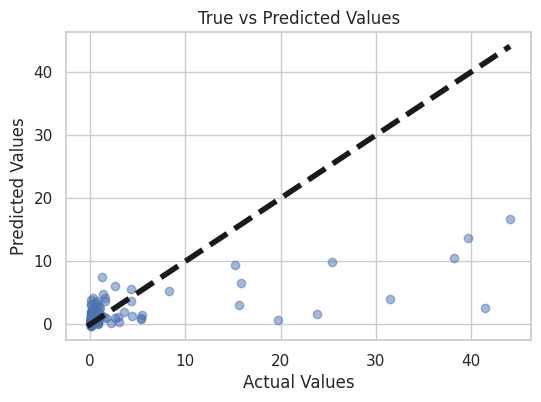

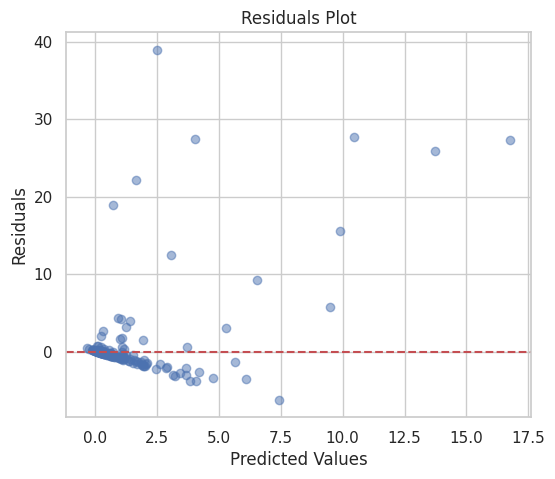

In [ ]:
import shap

cat_regressor = cb.CatBoostRegressor(verbose=0)
cat_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = cat_regressor.predict(test_x)

# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)
print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

# Create object that can calculate SHAP values
explainer = shap.TreeExplainer(cat_regressor)

# Calculate SHAP values for all of test_X
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
plt.figure(figsize=(3, 7))
plt.title("CatBoost - SHAP values for most important features")
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Plotting true vs predicted values
plt.figure(figsize=(6, 4))
plt.scatter(test_y, pred_y, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
# Use min and max from both actual and predicted values for a more accurate line
plt.plot([min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], [min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], 'k--', lw=4)
plt.show()

# Plotting residuals
residuals = test_y - pred_y
plt.figure(figsize=(6, 5))
plt.scatter(pred_y, residuals, alpha=0.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()


## SVR

Mean Absolute Error: 2.137784461190491
MSE: 53.87496350776084
RMSE: 7.339956642089982


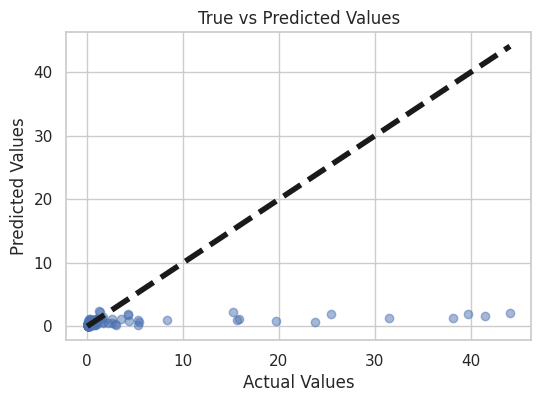

In [ ]:
# Create and fit the SVR model
svr = SVR()
svr.fit(train_x, train_y)

# Predictions for the SVR model (predictions are in transformed scale)
y_pred = svr.predict(test_x)

# Evaluate the SVR model in the original scale
mse = mean_squared_error(test_y, y_pred)
mape = mean_absolute_percentage_error(test_y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

# Plotting true vs predicted values in original scale
plt.figure(figsize=(6, 4))
plt.scatter(test_y, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.plot([min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], [min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], 'k--', lw=4)
plt.show()




## SVR C=1, epsilon=0.2)

Mean Absolute Error: 2.153352012400228
Mean Squared Error: 53.65724503128443


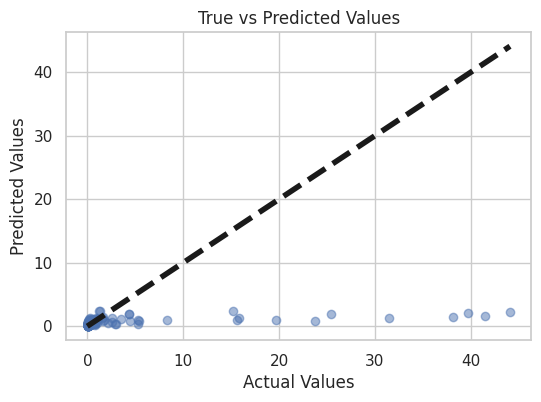

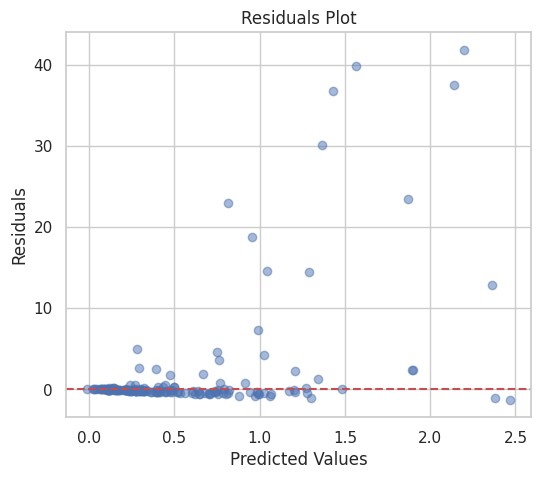

In [ ]:
model = SVR(C=1, epsilon=0.2)

# Fit the model
model.fit(train_x, train_y)

# Predict
y_pred = model.predict(test_x)

# Evaluate the model
print(f"Mean Absolute Error: {mean_absolute_error(test_y, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(test_y, y_pred)}")

# Plotting true vs predicted values
plt.figure(figsize=(6, 4))
plt.scatter(test_y, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
# Use min and max from both actual and predicted values for a more accurate line
plt.plot([min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], [min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], 'k--', lw=4)
plt.show()

# Plotting residuals
residuals = test_y - y_pred
plt.figure(figsize=(6, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()


## SVR development with different C_value

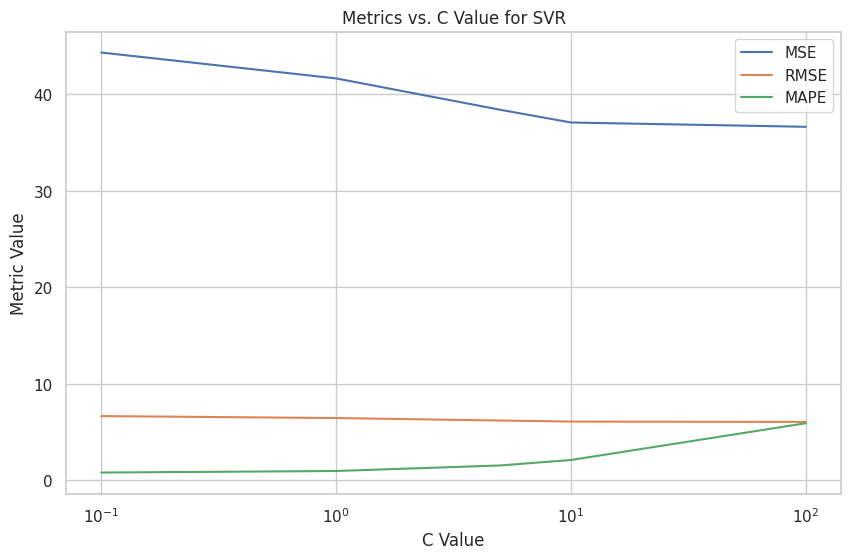

In [ ]:
# Define a range of C values to try
C_values = [0.1, 1, 5, 10, 100]  # Example: different C values

# Lists to store evaluation metrics
mse_values = []
rmse_values = []
r2_values = []
mape_values = []
# Iterate over different C values
for C_value in C_values:
    # Train SVR model
    svr = SVR(C=C_value)
    svr.fit(train_x, train_y)

    # Predictions for SVR model
    svr_predictions = svr.predict(test_x)

    # Evaluate the SVR model
    mse = mean_squared_error(test_y, svr_predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(test_y, svr_predictions)
    mape = mean_absolute_percentage_error(test_y, svr_predictions)
    # Append metrics to lists
    mse_values.append(mse)
    mape_values.append(mape)
    rmse_values.append(rmse)
    r2_values.append(r2)

# Plot the development of metrics for different C values
plt.figure(figsize=(10, 6))

plt.plot(C_values, mse_values, label='MSE')
plt.plot(C_values, rmse_values, label='RMSE')
plt.plot(C_values, mape_values, label='MAPE')



plt.xscale('log')  # Using logarithmic scale for better visualization if C values vary greatly
plt.xlabel('C Value')
plt.ylabel('Metric Value')
plt.title('Metrics vs. C Value for SVR')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
sns.set_style("ticks")

## LGB Regressor

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2198
[LightGBM] [Info] Number of data points in the train set: 687, number of used features: 45
[LightGBM] [Info] Start training from score 1.254864
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

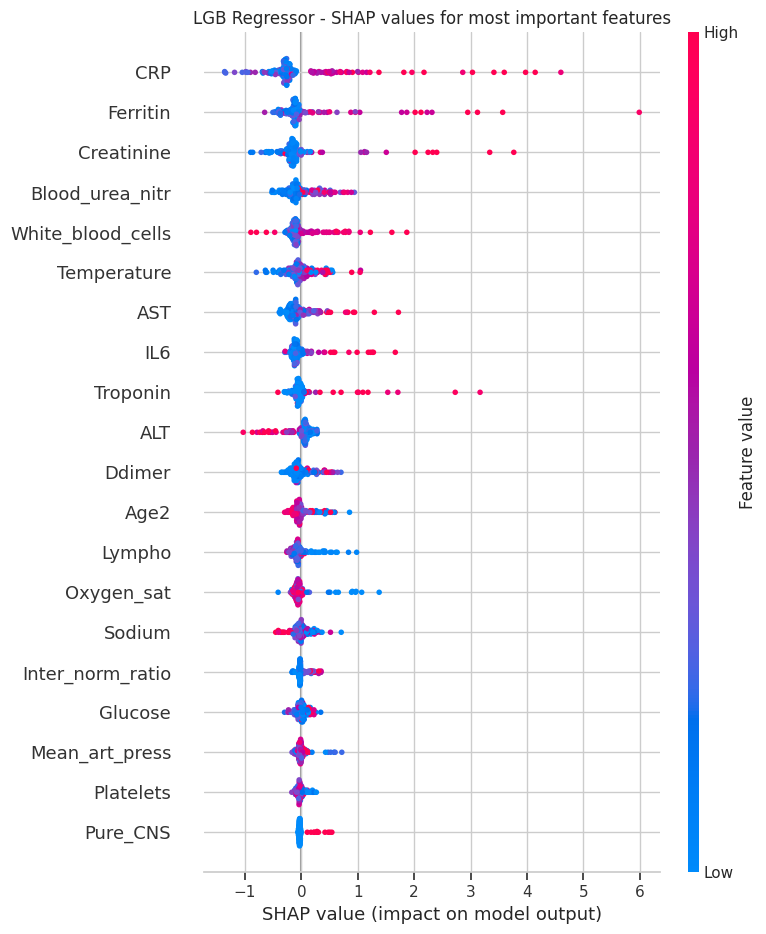

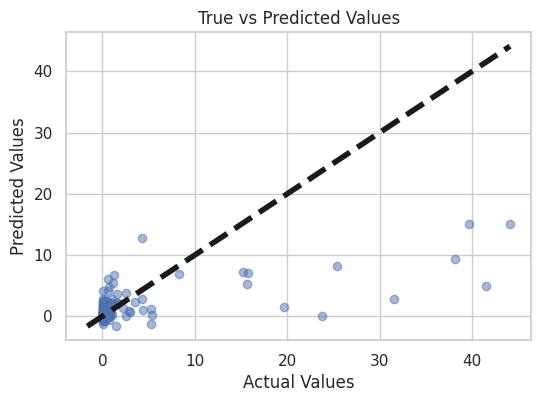

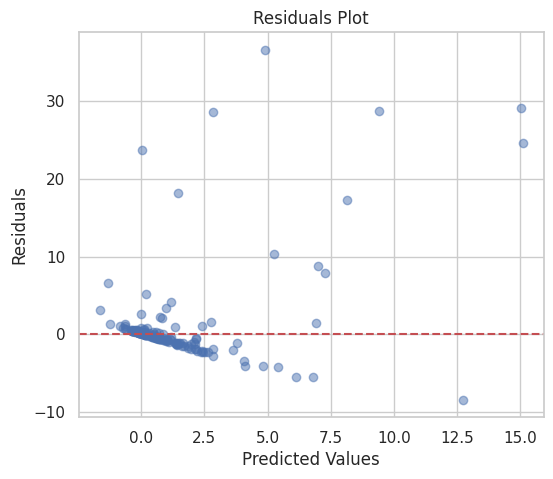

In [ ]:
# Create an LightGBM regression model
lgb_regressor = lgb.LGBMRegressor(random_state=42)
lgb_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = lgb_regressor.predict(test_x)

# Evaluate the LightGBM model
mse = mean_squared_error(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, pred_y)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

# Create object that can calculate SHAP values
explainer = shap.TreeExplainer(lgb_regressor)

# Calculate SHAP values for all of test_X
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
plt.figure(figsize=(3, 7))
plt.title("LGB Regressor - SHAP values for most important features")
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Plotting true vs predicted values
plt.figure(figsize=(6, 4))
plt.scatter(test_y, pred_y, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
# Use min and max from both actual and predicted values for a more accurate line
plt.plot([min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], [min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], 'k--', lw=4)
plt.show()

# Plotting residuals
residuals = test_y - pred_y
plt.figure(figsize=(6, 5))
plt.scatter(pred_y, residuals, alpha=0.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

## KNN regressor - ladenie hyperparametrov

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Since this is regression, using KNeighborsRegressor
knn = KNeighborsRegressor()

# Define the grid of hyperparameters to search
param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_percentage_error', verbose=1)

# Perform the grid search on the scaled data
grid_search.fit(X_train, y_train)

# Find the best hyperparameters
best_params = grid_search.best_params_
best_score = -grid_search.best_score_  # negated because scoring='neg_mean_absolute_percentage_error'

print('Best hyperparameters found:\n', best_params)
print(f'Best MAPE score from grid search: {best_score}')

# Evaluate the best model found by the grid search on the test data
best_knn = grid_search.best_estimator_
predictions = best_knn.predict(X_test)

# Calculate the MAPE for the test set
test_mape = mean_absolute_percentage_error(y_test, predictions)
print(f'Test MAPE of the best KNN model: {test_mape}')


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best hyperparameters found:
 {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Best MAPE score from grid search: 1.5408847841888247
Test MAPE of the best KNN model: 1.607593782840492


## Linear Regression

Mean Absolute Error: 2.6899517398890493
MSE: 42.582982185450966
RMSE: 6.525563744646968
R²: 0.2154300212825997


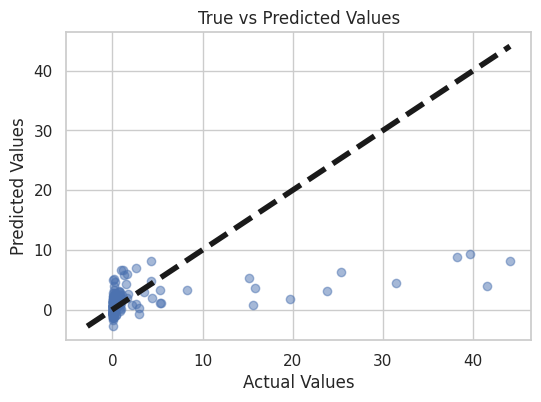

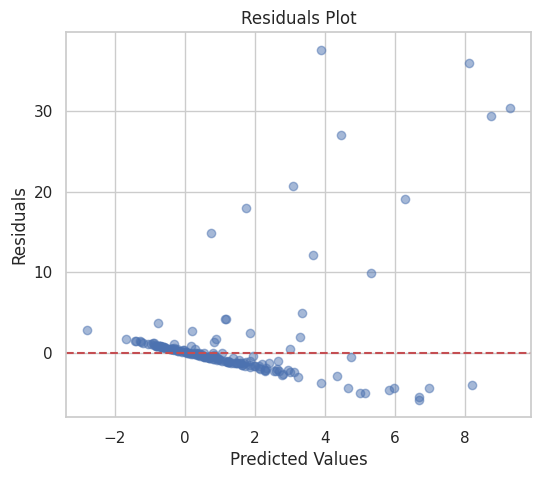

In [ ]:
linear_regressor = LinearRegression()
linear_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = linear_regressor.predict(test_x)

# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

# Plotting true vs predicted values
plt.figure(figsize=(6, 4))
plt.scatter(test_y, pred_y, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
# Use min and max from both actual and predicted values for a more accurate line
plt.plot([min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], [min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], 'k--', lw=4)
plt.show()

# Plotting residuals
residuals = test_y - pred_y
plt.figure(figsize=(6, 5))
plt.scatter(pred_y, residuals, alpha=0.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()